In [1]:
! pip install snowflake-connector-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 3.6 MB/s eta 0:00:00


In [2]:
import snowflake.connector

In [3]:
conn=snowflake.connector.connect(
    user="KxxxR",
    password="yyyyyy",
    account="BCROTQS-IJ54558",
    database="WATER_PORTABILITY",
    schema="PUBLIC",
    warehouse="COMPUTE_WH"
)

In [4]:
import pandas as pd
query='SELECT * FROM "WATER"'
df=pd.read_sql(query,conn)

/tmp/ipykernel_690/3883034437.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,conn)


In [5]:
conn.close()

In [6]:
df

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,NaN,204.890456,20791.31898,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.05786,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.54173,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.41744,8.059332,356.886136,363.266516,18.436525,100.341674,4.628771,0
4,9.092223,181.101509,17978.98634,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681736,47580.99160,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.80216,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.57822,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.86938,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [7]:
df.shape

(3276, 10)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PH               2785 non-null   float64
 1   HARDNESS         3276 non-null   float64
 2   SOLIDS           3276 non-null   float64
 3   CHLORAMINES      3276 non-null   float64
 4   SULFATE          2495 non-null   float64
 5   CONDUCTIVITY     3276 non-null   float64
 6   ORGANIC_CARBON   3276 non-null   float64
 7   TRIHALOMETHANES  3114 non-null   float64
 8   TURBIDITY        3276 non-null   float64
 9   POTABILITY       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [9]:
df.describe()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690300,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833605,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762125,8.114887,359.950170,481.792305,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196010,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [10]:
df.isnull().sum()

,0
PH,491
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,781
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,162
TURBIDITY,0
POTABILITY,0


In [11]:
from sklearn.impute import SimpleImputer
si=SimpleImputer(strategy='mean')
df[['PH','SULFATE','TRIHALOMETHANES']]=si.fit_transform(df[['PH','SULFATE','TRIHALOMETHANES']])

In [13]:
import numpy as np
from scipy.stats import zscore
sum=[]
for val in df.select_dtypes(include="number").columns:
  z_score=zscore(df[val])
  out=df[val][np.abs(z_score)>3]
  sum.append((val,len(out)))
print(sum)



[('PH', 28), ('HARDNESS', 18), ('SOLIDS', 20), ('CHLORAMINES', 20), ('SULFATE', 34), ('CONDUCTIVITY', 7), ('ORGANIC_CARBON', 4), ('TRIHALOMETHANES', 18), ('TURBIDITY', 9), ('POTABILITY', 0)]


In [14]:
df.isnull().sum()

,0
PH,0
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,0
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,0
TURBIDITY,0
POTABILITY,0


<Axes: >

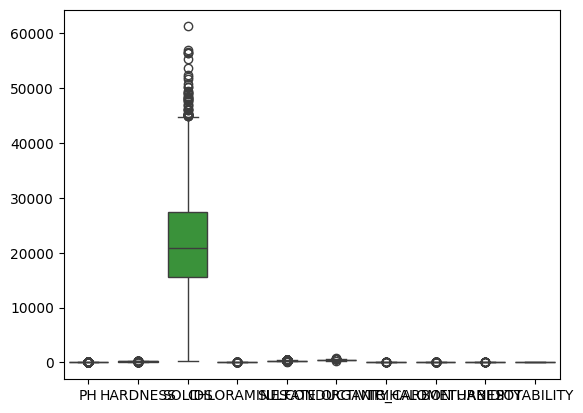

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.boxplot(df)

In [16]:
from scipy.stats import zscore
z_score=zscore(df)
df[np.abs(z_score)>3]

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
37,5.618064,304.235912,17281.97517,6.101084,333.775777,399.471566,12.265002,81.588992,2.896547,0
61,6.391354,213.017830,20965.47831,5.375560,327.650542,369.338121,13.758105,17.915723,3.923749,0
66,5.058109,238.569380,34873.93452,8.983276,374.433505,669.725086,13.353181,76.521800,5.106656,0
80,1.844538,233.764343,28689.59578,7.724432,333.775777,410.387264,15.611859,54.299444,5.013463,0
88,10.155440,300.292476,12652.36298,6.655126,398.647786,487.459131,9.347634,67.919789,5.002467,0
...,...,...,...,...,...,...,...,...,...,...
3190,9.293622,193.061723,50166.53332,6.301884,333.775777,365.439202,14.225917,98.625457,3.661882,1
3221,4.034063,303.702627,33219.07455,4.425559,333.775777,494.320907,13.415230,72.012642,5.024742,1
3226,7.870853,210.627825,51731.82055,6.190963,333.775777,533.291262,15.029899,84.335058,4.221614,1
3269,11.491011,94.812545,37188.82602,9.263166,258.930600,439.893618,16.172755,41.558501,4.369264,1


In [17]:
for val in df.select_dtypes(include=['number']).columns:
  lower=df[val].quantile(0.05)
  upper=df[val].quantile(0.95)
  df[val]=df[val].clip(lower,upper)

In [18]:
from scipy.stats import zscore
import numpy as np
sum=[]
for val in df.select_dtypes(include=['int64','float64']).columns:
  z_score=zscore(df[val])
  out=df[val][np.abs(z_score)>3]
  sum.append((val,len(out)))
print(sum)

[('PH', 0), ('HARDNESS', 0), ('SOLIDS', 0), ('CHLORAMINES', 0), ('SULFATE', 0), ('CONDUCTIVITY', 0), ('ORGANIC_CARBON', 0), ('TRIHALOMETHANES', 0), ('TURBIDITY', 0), ('POTABILITY', 0)]


In [19]:
sum=[]
for val in df.select_dtypes(['int64','float64']).columns:
  q1=df[val].quantile(0.25)
  q3=df[val].quantile(0.75)
  IQR=q3-q1
  lower=q1-1.5*IQR
  upper=q3+1.5*IQR
  count=df[(df[val]<lower)|(df[val]>upper)]
  sum.append((val,len(count)))
print(sum)



[('PH', 0), ('HARDNESS', 0), ('SOLIDS', 0), ('CHLORAMINES', 0), ('SULFATE', 0), ('CONDUCTIVITY', 0), ('ORGANIC_CARBON', 0), ('TRIHALOMETHANES', 0), ('TURBIDITY', 0), ('POTABILITY', 0)]


<Axes: >

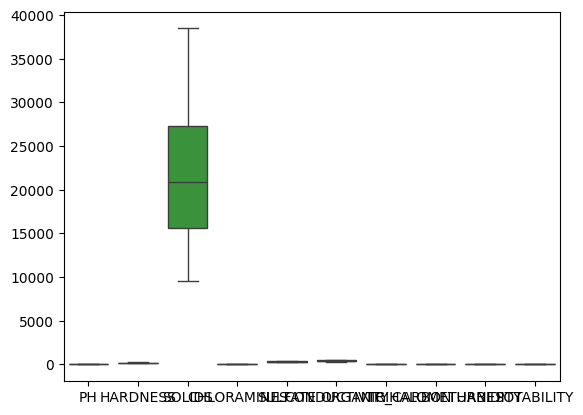

In [20]:
sns.boxplot(df)

In [46]:
x=df.drop(['POTABILITY'],axis=1)
y=df['POTABILITY']

In [47]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
x=ss.fit_transform(x)

In [48]:
from sklearn.svm import SVC



In [49]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [50]:
svc=SVC(kernel='rbf')
svc.fit(x_train,y_train)
y_pred=svc.predict(x_test)

In [51]:
from sklearn.metrics import classification_report as cr
print(cr(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.69      0.89      0.78       412
           1       0.65      0.34      0.44       244

    accuracy                           0.68       656
   macro avg       0.67      0.61      0.61       656
weighted avg       0.68      0.68      0.65       656

